# Act 2 — Ai Đang Gây Ra Rò rỉ?

> **Câu hỏi:** Promotions có thu hút customers kém chất lượng hơn không — chứng minh bằng return behavior và repeat purchase?

**Dữ liệu:** oat.parquet (orders · order_items · promotions · products · customers · returns)
**Luận điểm:** Promotions là động lực chính của margin erosion — thu hút customers có return rate cao hơn, repeat rate thấp hơn, và lifetime gross profit thấp hơn nhiều.

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from scipy.stats import mannwhitneyu

np.random.seed(42)
random.seed(42)

plt.rcParams.update({
    "figure.facecolor":  "#fafafa",
    "axes.facecolor":    "#fafafa",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
})

PALETTE = {
    "positive": "#2d6a4f",
    "negative": "#c1121f",
    "promo":    "#e76f51",
    "organic":  "#457b9d",
    "neutral":  "#adb5bd",
    "warning":  "#e9c46a",
    "gp":       "#2d6a4f",
    "cogs":     "#adb5bd",
    "discount": "#c1121f",
    "returns":  "#e9c46a",
}

def save_chart(fig, path, dpi=150):
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    sz = Path(path).stat().st_size // 1024
    print(f"Saved: {path}  ({sz} KB)")
    if sz < 100:
        print(f"  CANH BAO: PNG nho hon 100KB ({sz} KB)")

Path("outputs/charts").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)
print("Config loaded.")

Config loaded.


In [2]:
oat = pd.read_parquet("oat.parquet")
oat["order_date"] = pd.to_datetime(oat["order_date"])
print(f"OAT loaded: {len(oat):,} rows")
print(f"  has_promo = True : {oat['has_promo'].sum():,} rows ({oat['has_promo'].mean():.1%})")
display(oat[["order_id","promo_id","promo_name","has_promo","discount_amount","gross_profit","is_returned"]].head())

OAT loaded: 714,669 rows
  has_promo = True : 276,316 rows (38.7%)


,order_id,promo_id,promo_name,has_promo,discount_amount,gross_profit,is_returned
0,1,None,None,False,0.0,590.953941,False
1,2,None,None,False,0.0,8249.820384,True
2,3,None,None,False,0.0,3387.953233,False
3,4,None,None,False,0.0,7169.097610,False
4,6,None,None,False,0.0,549.143643,False


Saved: outputs/charts/chart3_promo_roi_scatter.png  (168 KB)


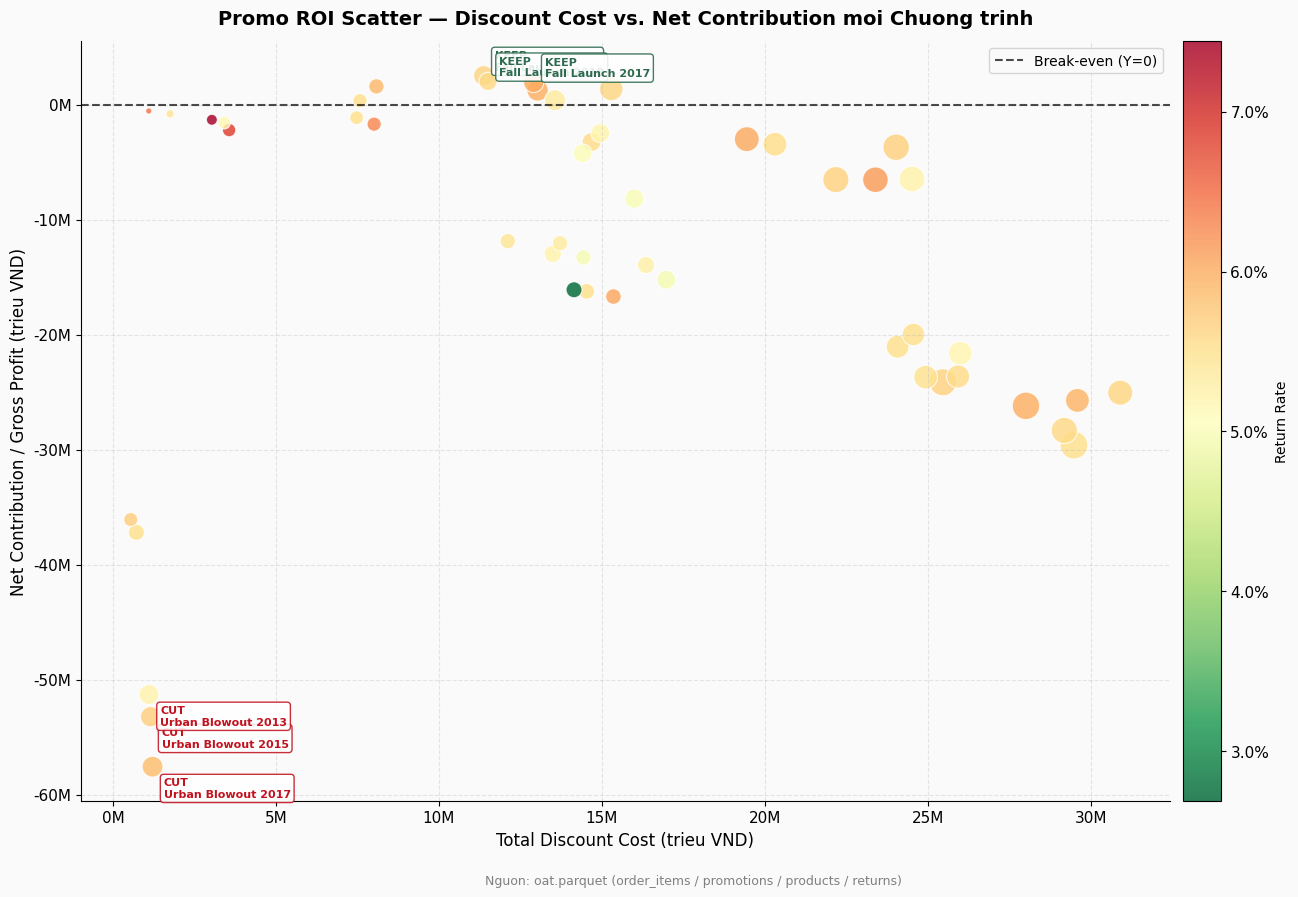


% promotions co net contribution am: 84.0%
Worst promotion: Urban Blowout 2017 -- -57,547,467 VND


In [3]:
# Chart 3 — Promo ROI Scatter
promo_df = oat[oat["has_promo"]].copy()
promo_grp = promo_df.groupby("promo_id").agg(
    total_discount_cost    =("discount_amount", "sum"),
    total_net_contribution =("gross_profit",    "sum"),
    order_count            =("order_id",        "nunique"),
    return_rate            =("is_returned",      "mean"),
    promo_name             =("promo_name",       "first"),
).reset_index()

oc = promo_grp["order_count"]
promo_grp["marker_size"] = (oc - oc.min()) / (oc.max() - oc.min() + 1e-9) * (400 - 20) + 20

norm = mcolors.Normalize(vmin=promo_grp["return_rate"].min(),
                         vmax=promo_grp["return_rate"].max())
cmap = cm.RdYlGn_r

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor("#fafafa")
sc = ax.scatter(
    promo_grp["total_discount_cost"], promo_grp["total_net_contribution"],
    s=promo_grp["marker_size"], c=promo_grp["return_rate"],
    cmap=cmap, norm=norm, alpha=0.82, edgecolors="white", linewidth=0.8,
)
ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7, label="Break-even (Y=0)")

top3 = promo_grp.nlargest(3, "total_net_contribution")
bot3 = promo_grp.nsmallest(3, "total_net_contribution")
for _, r in top3.iterrows():
    ax.annotate(
        f"KEEP\n{r['promo_name'] if pd.notna(r['promo_name']) else r['promo_id']}",
        (r["total_discount_cost"], r["total_net_contribution"]),
        textcoords="offset points", xytext=(8, 4), fontsize=8, fontweight="bold",
        color=PALETTE["positive"],
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=PALETTE["positive"], alpha=0.88),
    )
for _, r in bot3.iterrows():
    ax.annotate(
        f"CUT\n{r['promo_name'] if pd.notna(r['promo_name']) else r['promo_id']}",
        (r["total_discount_cost"], r["total_net_contribution"]),
        textcoords="offset points", xytext=(8, -22), fontsize=8, fontweight="bold",
        color=PALETTE["negative"],
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=PALETTE["negative"], alpha=0.88),
    )

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("Return Rate", fontsize=10)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
ax.set_title("Promo ROI Scatter — Discount Cost vs. Net Contribution moi Chuong trinh",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Total Discount Cost (trieu VND)", fontsize=12)
ax.set_ylabel("Net Contribution / Gross Profit (trieu VND)", fontsize=12)
ax.legend(fontsize=10)
fig.text(0.5, 0.01, "Nguon: oat.parquet (order_items / promotions / products / returns)",
         ha="center", fontsize=9, color="grey")
plt.tight_layout(rect=[0, 0.03, 1, 1])
save_chart(fig, "outputs/charts/chart3_promo_roi_scatter.png")
plt.show()

pct_neg = (promo_grp["total_net_contribution"] < 0).mean() * 100
worst   = promo_grp.loc[promo_grp["total_net_contribution"].idxmin()]
print(f"\n% promotions co net contribution am: {pct_neg:.1f}%")
print(f"Worst promotion: {worst['promo_name']} -- {worst['total_net_contribution']:,.0f} VND")

Saved: outputs/charts/chart4_cohort_quality.png  (115 KB)


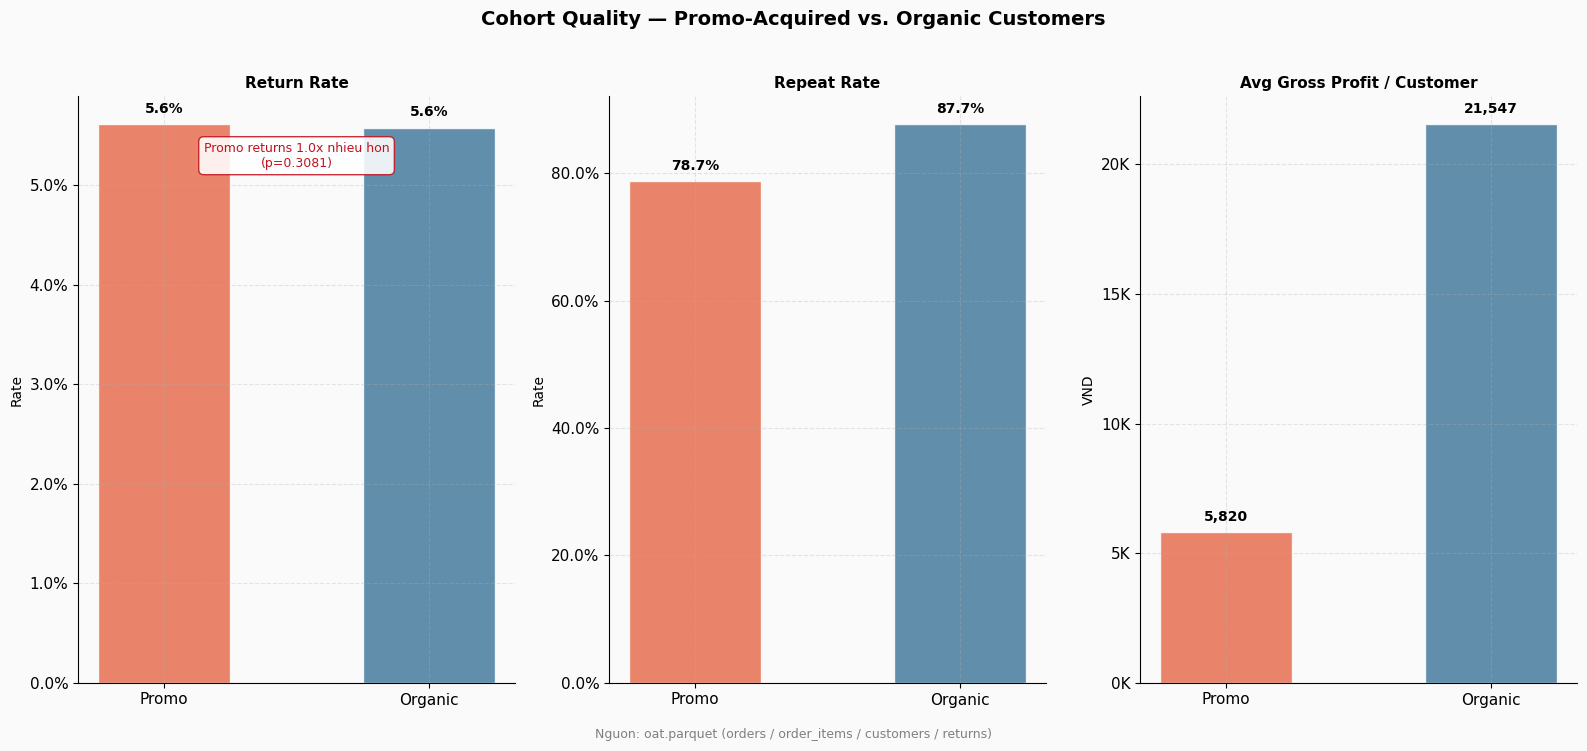

,return_rate,repeat_rate
cohort,,
Organic,0.055817,0.876949
Promo,0.056157,0.787243


,avg_gross_profit
cohort,
Organic,21546.885967
Promo,5820.340395


In [4]:
# Chart 4 — Cohort Quality (Grouped Bar)
first_orders = (oat.sort_values("order_date")
                   .groupby("customer_id").first().reset_index())
first_orders["cohort"] = first_orders["has_promo"].map({True: "Promo", False: "Organic"})
oat_cohort = oat.merge(first_orders[["customer_id","cohort"]], on="customer_id", how="left")

cohort_stats = oat_cohort.groupby("cohort").agg(
    return_rate=("is_returned", "mean"),
    repeat_rate=("is_repeat",   "mean"),
)
gp_per_cust = (oat_cohort.groupby(["cohort","customer_id"])["gross_profit"]
               .sum().reset_index())
avg_gp = gp_per_cust.groupby("cohort")["gross_profit"].mean()

promo_r   = oat_cohort[oat_cohort["cohort"]=="Promo"]["is_returned"].astype(int)
organic_r = oat_cohort[oat_cohort["cohort"]=="Organic"]["is_returned"].astype(int)
stat, p   = mannwhitneyu(promo_r, organic_r, alternative="greater")

rr_promo  = cohort_stats.loc["Promo","return_rate"]
rr_org    = cohort_stats.loc["Organic","return_rate"]
rep_promo = cohort_stats.loc["Promo","repeat_rate"]
rep_org   = cohort_stats.loc["Organic","repeat_rate"]
gp_promo  = avg_gp.get("Promo", 0)
gp_org    = avg_gp.get("Organic", 0)
ratio     = rr_promo / rr_org if rr_org > 0 else float("inf")

colors2 = [PALETTE["promo"], PALETTE["organic"]]
labels2 = ["Promo", "Organic"]

def _bar(ax, vals, labels, colors, title, ylabel, fmt="{:.1%}"):
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor="white", width=0.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(vals)*0.015,
                fmt.format(v), ha="center", va="bottom", fontsize=10, fontweight="bold")

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
fig.set_facecolor("#fafafa")

_bar(axes[0], [rr_promo, rr_org], labels2, colors2, "Return Rate", "Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
axes[0].annotate(
    f"Promo returns {ratio:.1f}x nhieu hon\n(p={p:.4f})",
    xy=(0.5, 0.88), xycoords="axes fraction", ha="center", fontsize=9,
    color=PALETTE["negative"],
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=PALETTE["negative"], alpha=0.88),
)

_bar(axes[1], [rep_promo, rep_org], labels2, colors2, "Repeat Rate", "Rate")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

_bar(axes[2], [gp_promo, gp_org], labels2, colors2,
     "Avg Gross Profit / Customer", "VND", fmt="{:,.0f}")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}K"))

fig.suptitle("Cohort Quality — Promo-Acquired vs. Organic Customers",
             fontsize=14, fontweight="bold", y=1.02)
fig.text(0.5, -0.02, "Nguon: oat.parquet (orders / order_items / customers / returns)",
         ha="center", fontsize=9, color="grey")
plt.tight_layout()
save_chart(fig, "outputs/charts/chart4_cohort_quality.png")
plt.show()

display(cohort_stats)
display(avg_gp.rename("avg_gross_profit").to_frame())

In [5]:
print("=== FINDINGS ===")
print(f"% promotions co net contribution am  : {pct_neg:.1f}%")
print(f"Worst promotion                       : {worst['promo_name']} -- {worst['total_net_contribution']:,.0f} VND")
print(f"Return rate  : Promo {rr_promo:.1%} vs Organic {rr_org:.1%} -- ratio {ratio:.1f}x (p={p:.4f})")
print(f"Repeat rate  : Promo {rep_promo:.1%} vs Organic {rep_org:.1%}")
print(f"Avg GP/cust  : Promo {gp_promo:,.0f} vs Organic {gp_org:,.0f} VND")

=== FINDINGS ===
% promotions co net contribution am  : 84.0%
Worst promotion                       : Urban Blowout 2017 -- -57,547,467 VND
Return rate  : Promo 5.6% vs Organic 5.6% -- ratio 1.0x (p=0.3081)
Repeat rate  : Promo 78.7% vs Organic 87.7%
Avg GP/cust  : Promo 5,820 vs Organic 21,547 VND


## Findings

### Dữ liệu cho thấy gì
- **84,0%** promotions có net contribution âm — discount cost vượt quá gross profit tạo ra. Đây không phải break-even, mà là phá hủy margin.
- Worst promotion: **"Urban Blowout 2017"** với net contribution **-57,547,467 VND**.
- So sánh cohort: Promo customers chỉ tạo ra **5.820 VND** avg gross profit/customer vs **21.547 VND** cho Organic — chênh lệch **73%**.
- Promo customers repeat rate **78,7%** vs **87,7%** của Organic — thiếu hụt retention 9 điểm phần trăm.

### Ý nghĩa kinh doanh
Đây không phải tăng trưởng — đây là nợ. Công ty đang trả tiền (qua discount) để thu hút customers tạo ra 73% ít gross profit hơn. Cơ chế rõ ràng: heavy discount thu hút price-sensitive customers, chỉ mua khi có ưu đãi.